# Load QM9 Dataset

In [1]:
import os
from pathlib import Path
from torch_geometric.datasets import QM9

DATA_ROOT = Path.cwd().parent / "data" / "QM9"

dataset = QM9(DATA_ROOT)

/home/doterog/repos/uva/research/drifting-experiments/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/doterog/repos/uva/research/drifting-experiments/.venv/lib/python3.11/site-packages/torch_geometric/data/dataset.py:115: UserWarning: The `pre_transform` argument differs from the one used in the pre-processed version of this dataset. If you want to make use of another pre-processing technique, pass `force_reload=True` explicitly to reload the dataset.
  self._process()


# Define EGNN, Loss, and Training Loop

- Reminder: norm_diff and node_attr are dead params
- We are missing the normalization factor that is passed with the sum of both GCNs

In [2]:
import torch
from torch import nn
from torch_geometric.nn import MessagePassing

class TypeGCN(MessagePassing):
    propagate_type = {"type_feat": torch.Tensor, "edge_attr": torch.Tensor}

    def __init__(
        self, hidden_nf: int, attention: bool = True, aggr_type: str = "sum"
    ):
        super().__init__(aggr=aggr_type)

        in_message_dim = hidden_nf * 2 + 2
        self.message_mlp = nn.Sequential(
            nn.Linear(in_message_dim, in_message_dim),
            nn.SiLU(),
            nn.Linear(in_message_dim, hidden_nf),
        )

        self.update_mlp = nn.Sequential(
            nn.Linear(hidden_nf * 2, hidden_nf),
            nn.SiLU(),
            nn.Linear(hidden_nf, hidden_nf),
        )

        self.attention = attention
        if self.attention:
            self.att_mlp = nn.Sequential(
                nn.Linear(hidden_nf, 1),
                nn.Sigmoid(),
            )

    def message(
        self,
        type_feat_i: torch.Tensor,
        type_feat_j: torch.Tensor,
        edge_attr: torch.Tensor
    ) -> torch.Tensor:
        input_tensor = torch.cat(
            [type_feat_i, type_feat_j, edge_attr],
            dim=-1,
        )
        out = self.message_mlp(input_tensor)

        if self.attention:
            att_val = self.att_mlp(out)
            return out * att_val

        return out

    def update(self, aggr_out: torch.Tensor, type_feat: torch.Tensor) -> torch.Tensor:
        out = torch.cat([aggr_out, type_feat], dim=-1)
        return type_feat + self.update_mlp(out)

    def forward(
        self, type_feat: torch.Tensor, edge_index: torch.Tensor, edge_attr: torch.Tensor
    ) -> torch.Tensor:
        return self.propagate(
            edge_index, type_feat=type_feat, edge_attr=edge_attr
        )


class PosGCN(MessagePassing):
    propagate_type = {
        "type_feat": torch.Tensor,
        "scaled_dir_vector": torch.Tensor,
        "edge_attr": torch.Tensor,
    }

    def __init__(
        self,
        hidden_nf: int,
        tanh_coord_updates: bool = True,
        coords_range: float = 15.0,
        aggr_type: str = "sum",
    ):
        super().__init__(aggr=aggr_type)

        in_message_dim = hidden_nf * 2 + 2

        layer = nn.Linear(hidden_nf, 1, bias=False)
        torch.nn.init.xavier_uniform_(layer.weight, gain=0.001)

        self.coord_mlp = nn.Sequential(
            nn.Linear(in_message_dim, hidden_nf),
            nn.SiLU(),
            nn.Linear(hidden_nf, hidden_nf),
            nn.SiLU(),
            layer,
        )

        self.tanh_coord_updates = tanh_coord_updates
        self.coords_range = coords_range

    def message(
        self,
        type_feat_i: torch.Tensor,
        type_feat_j: torch.Tensor,
        edge_attr: torch.Tensor,
        scaled_dir_vector: torch.Tensor,
    ) -> torch.Tensor:
        input_tensor = torch.cat([type_feat_i, type_feat_j, edge_attr], dim=-1)
        weight = self.coord_mlp(input_tensor)
        if self.tanh_coord_updates:
            weight = torch.tanh(weight) * self.coords_range
        return scaled_dir_vector * weight

    def forward(
        self,
        pos: torch.Tensor,
        type_feat: torch.Tensor,
        edge_index: torch.Tensor,
        edge_attr: torch.Tensor,
        scaled_dir_vector: torch.Tensor,
    ) -> torch.Tensor:
        delta = self.propagate(
            edge_index,
            type_feat=type_feat,
            edge_attr=edge_attr,
            scaled_dir_vector=scaled_dir_vector,
        )
        return pos + delta


class EquivariantBlock(nn.Module):
    def __init__(
        self,
        hidden_nf: int,
        n_layers: int = 1,
        attention: bool = True,
        tanh_coord_updates: bool = True,
        coords_range: float = 15.0,
        aggr_type: str = "sum",
    ):
        super().__init__()

        self.type_update = nn.ModuleList(
            [
                TypeGCN(hidden_nf, attention=attention, aggr_type=aggr_type)
                for _ in range(n_layers)
            ]
        )

        self.coord_update = PosGCN(
            hidden_nf,
            tanh_coord_updates=tanh_coord_updates,
            coords_range=coords_range,
            aggr_type=aggr_type,
        )

    def forward(
        self,
        type_feat: torch.Tensor,
        pos: torch.Tensor,
        edge_index: torch.Tensor,
        edge_attr: torch.Tensor,
        scaled_dir_vector: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        for type_gcn in self.type_update:
            type_feat = type_gcn(
                type_feat=type_feat,
                edge_index=edge_index,
                edge_attr=edge_attr
            )

        pos = self.coord_update(
            pos=pos,
            type_feat=type_feat,
            edge_index=edge_index,
            edge_attr=edge_attr,
            scaled_dir_vector=scaled_dir_vector,
        )

        return type_feat, pos

def compute_edge_properties(
    pos: torch.Tensor, edge_index: torch.Tensor, norm_constant: float = 1.0
) -> tuple[torch.Tensor, torch.Tensor]:
    src, dst = edge_index
    dist = pos[src] - pos[dst]
    squared_norm = dist.pow(2).sum(dim=-1)
    norm = squared_norm.sqrt()
    scaled_dir_vector = dist / (norm.unsqueeze(-1) + norm_constant)
    return squared_norm, scaled_dir_vector

class EGNN(nn.Module):
    def __init__(
        self,
        num_atom_types: int,
        num_blocks: int = 9,
        hidden_nf: int = 256,
        num_layers_per_block: int = 1,
        attention: bool = True,
        tanh_coord_updates: bool = True,
        coords_range: float = 15.0,
        aggr_type: str = "sum",
    ):
        super().__init__()
        self.type_embedding = nn.Linear(num_atom_types, hidden_nf)
        self.type_embedding_out = nn.Linear(hidden_nf, num_atom_types)
        self.blocks = nn.ModuleList(
            [
                EquivariantBlock(
                    hidden_nf,
                    n_layers=num_layers_per_block,
                    attention=attention,
                    tanh_coord_updates=tanh_coord_updates,
                    coords_range=coords_range,
                    aggr_type=aggr_type,
                )
                for _ in range(num_blocks)
            ]
        )

    def forward(
        self,
        pos_noise: torch.Tensor,
        type_noise: torch.Tensor,
        edge_index: torch.Tensor,
        return_change_in_pos: bool = False,
    ) -> tuple[torch.Tensor, torch.Tensor]:

        gen_feats = self.type_embedding(type_noise)
        gen_pos = pos_noise
        initial_squared_norm, _ = compute_edge_properties(gen_pos, edge_index)

        pos_list = []
        if return_change_in_pos:
            pos_list.append(gen_pos.clone())

        for block in self.blocks:
            squared_norm, scaled_dir_vector = compute_edge_properties(gen_pos, edge_index)
            edge_attr = torch.cat(
                [initial_squared_norm.unsqueeze(-1), squared_norm.unsqueeze(-1)],
                dim=-1,
            )
            gen_feats, gen_pos = block(
                type_feat=gen_feats,
                pos=gen_pos,
                edge_index=edge_index,
                scaled_dir_vector=scaled_dir_vector,
                edge_attr=edge_attr,
            )
            if return_change_in_pos:
                pos_list.append(gen_pos.clone())

        gen_types = self.type_embedding_out(gen_feats)

        if return_change_in_pos:
            return gen_pos, gen_types, pos_list
        return gen_pos, gen_types

# Drifting Fields

In [10]:
def compute_euclidean_drifting_field(gen_mol, real_mol, sigma = 1.0):
    n_gen = gen_mol.size(0)
    n_real = real_mol.size(0)

    targets = torch.cat([gen_mol, real_mol], dim=0)

    # [N_gen, N_targets, D]
    diffs = targets.unsqueeze(0) - gen_mol.unsqueeze(1)

    # [N_gen, N_targets]
    sq_dists = (diffs * diffs).sum(dim=-1)

    kernel = torch.exp(-sq_dists / (2 * sigma**2))

    kernel_neg, kernel_pos = torch.split(kernel, [n_gen, n_real], dim=1)
    diffs_neg, diffs_pos = torch.split(diffs, [n_gen, n_real], dim=1)

    weighted_neg = kernel_neg.unsqueeze(-1) * diffs_neg
    weighted_pos = kernel_pos.unsqueeze(-1) * diffs_pos

    Z_neg = kernel_neg.sum(dim=1, keepdim=True)
    Z_pos = kernel_pos.sum(dim=1, keepdim=True)

    v_neg = weighted_neg.sum(dim=1) / (Z_neg + 1e-8)
    v_pos = weighted_pos.sum(dim=1) / (Z_pos + 1e-8)
    return v_pos - v_neg

## Geometrical Fns

In [65]:
import torch


def sphere_normalize(x: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """
    Normalize each position independently onto S^3.
    """
    return x / x.norm(dim=-1, keepdim=True).clamp_min(eps)


def probs_to_sphere(p: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """
    Map simplex probabilities to positive orthant of the sphere:
        phi(p) = sqrt(p)
    p: [N_atoms, 5], sum=1 along last dim
    Returns x in S^3_+ at each position: [N_atoms, 5]
    """
    p = p.clamp_min(eps)
    p = p / p.sum(dim=-1, keepdim=True).clamp_min(eps)
    x = torch.sqrt(p)
    return sphere_normalize(x, eps)


def sphere_to_probs(x: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """
    Inverse map of phi on S^3_+:
        p_i = x_i^2
    x: [N_atoms, 5]
    returns probs: [N_atoms, 5]
    """
    x = sphere_normalize(x, eps).clamp_min(0.0)
    p = x.pow(2)
    return p / p.sum(dim=-1, keepdim=True).clamp_min(eps)


def sphere_project_tangent(x: torch.Tensor, v: torch.Tensor) -> torch.Tensor:
    """
    Project v onto tangent space at x, positionwise.
    x, v: [N_atoms, 5]
    """
    return v - (x * v).sum(dim=-1, keepdim=True) * x


def product_tangent_norm(v: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """
    Product metric norm:
        ||v||_g^2 = sum_l ||v_l||_2^2
    v: [N_atoms, 5]
    returns: [N_atoms, 1]
    """
    return torch.clamp(torch.norm(v, dim=-1, keepdim=True), min=1e-8)


def sphere_log(x: torch.Tensor, y: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """
    Positionwise sphere log map on S^3.

    x, y: [N_atoms, 5], each position normalized.
    returns: [N_atoms, 5], tangent at x
    """
    x = sphere_normalize(x, eps)
    y = sphere_normalize(y, eps)

    dot = (x * y).sum(dim=-1, keepdim=True).clamp(-1.0 + 1e-7, 1.0 - 1e-7)
    theta = torch.acos(dot)  # [..., L, 1]

    u = y - dot * x
    u_norm = u.norm(dim=-1, keepdim=True)

    scale = theta / u_norm.clamp_min(eps)
    out = scale * u

    small = theta < 1e-5
    first_order = sphere_project_tangent(x, y - x)
    out = torch.where(small, first_order, out)
    return sphere_project_tangent(x, out)


def sphere_exp(x: torch.Tensor, v: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """
    Positionwise sphere exp map on S^3.

    x: [N_atoms, 5] normalized
    v: [N_atoms, 5] tangent at x
    returns: [N_atoms, 5] on sphere
    """
    x = sphere_normalize(x, eps)
    v = sphere_project_tangent(x, v)

    v_norm = v.norm(dim=-1, keepdim=True)
    direction = v / v_norm.clamp_min(eps)

    out = torch.cos(v_norm) * x + torch.sin(v_norm) * direction
    approx = sphere_normalize(x + v, eps)

    out = torch.where(v_norm < 1e-5, approx, out)
    return sphere_normalize(out, eps)


def geodesic_distance(
    x: torch.Tensor,  # [Num_mol, max_atoms, 5]
    y: torch.Tensor,  # [Num_mol, max_atoms, 5]
    eps: float = 1e-8,
) -> torch.Tensor:
    x = sphere_normalize(x, eps)
    y = sphere_normalize(y, eps)

    dot = (x * y).sum(dim=-1).clamp(-1.0 + 1e-7, 1.0 - 1e-7)
    return torch.acos(dot)  # [N_mol, max_atoms]


def pairwise_geodesic_distance(x: torch.Tensor, y: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """
    Compute pairwise geodesic distance between two sets of points on the sphere.

    x: [N_mol, max_atoms, 5]
    y: [N_mol, max_atoms, 5]
    returns: [N_mol, max_atoms]
    """
    # Project both inputs onto the unit sphere so all points have norm 1
    x = sphere_normalize(x, eps)
    y = sphere_normalize(y, eps)

    # Dot product between every (x_i, y_j) pair across the last (channel) dim.
    # Shape: [N_mol_x, N_mol_y, max_atoms]. Clamped to keep acos numerically stable.
    dot = torch.einsum("blc,nlc->bnl", x, y).clamp(-1.0 + 1e-7, 1.0 - 1e-7)

    # Geodesic angle between each pair — the arc length on the unit sphere
    theta = torch.acos(dot)

    # Squared geodesic distance per (molecule, molecule) pair, summed over atoms
    sq_dists = theta.pow(2).sum(dim=-1).clamp_min(eps)

    # Component of y orthogonal to x in the tangent plane at x.
    # This is the direction of the geodesic from x toward y.
    u = y.unsqueeze(0) - dot.unsqueeze(-1) * x.unsqueeze(1)
    u_norm = u.norm(dim=-1, keepdim=True)

    # Rescale the tangent direction so its magnitude equals the arc length theta,
    # giving the logarithmic map: the tangent vector whose geodesic lands at y
    scale = theta.unsqueeze(-1) / u_norm.clamp_min(eps)
    out = scale * u

    # For nearly-identical points (theta ≈ 0) the formula above is numerically
    # unstable (0/0), so fall back to a first-order linear approximation instead
    small = theta.unsqueeze(-1) < 1e-5
    first_order = sphere_project_tangent(x.unsqueeze(1), y.unsqueeze(0) - x.unsqueeze(1))

    out = torch.where(small, first_order, out)

    # Final projection onto the tangent plane at x to ensure the output vector
    # is truly tangent to the sphere (corrects any floating-point drift)
    diff = sphere_project_tangent(x.unsqueeze(1), out)

    return sq_dists, diff

def compute_geodesic_drifting_field(gen_types, real_types, sigma=1.0, eps=1e-8):

    # sq_dists have shape [N_gen, N_gen] and [N_gen, N_real]
    # diff have shape [N_gen, N_gen, N_atoms, 5] and [N_gen, N_real, N_atoms, 5]
    sq_dists_neg, diff_neg = pairwise_geodesic_distance(gen_types, gen_types, eps)
    sq_dists_pos, diff_pos = pairwise_geodesic_distance(gen_types, real_types, eps)

    # The kernel has shape [N_gen, N_gen] and [N_gen, N_real]
    kernel_neg = torch.exp(-sq_dists_neg / (2 * sigma**2))
    kernel_pos = torch.exp(-sq_dists_pos / (2 * sigma**2))

    # We unsqueeze twice to get shape
    # [N_gen, N_gen, 1, 1] and [N_gen, N_real, 1, 1]
    # so we can multiply with diff
    kernel_neg = kernel_neg.unsqueeze(-1).unsqueeze(-1)
    kernel_pos = kernel_pos.unsqueeze(-1).unsqueeze(-1)

    # Calculate gradient of kernels towards generated input
    # a.ka. weighted diffs
    # shape is [N_gen, N_gen, N_atoms, 5] and [N_gen, N_real, N_atoms, 5]
    weighted_neg = (diff_neg * kernel_neg) / (sigma**2)
    weighted_pos = (diff_pos * kernel_pos) / (sigma**2)

    # Compute normalization constants by summing the kernels over
    # the second (target molecule) dimension
    # Shape is [N_gen, 1, 1, 1] for both
    # Remember two additional unsqueezes from before
    Z_neg = kernel_neg.sum(dim=1, keepdim=True).clamp_min(eps)
    Z_pos = kernel_pos.sum(dim=1, keepdim=True).clamp_min(eps)

    # Drifting positive direction
    # Sum over the second (target molecule) dimension,
    # then divide by normalization constant
    # Sum across targets is shape [N_gen, N_atoms, 5]
    # Hence we squeeze dim 1 from Z to get shape [N_gen, 1, 1] for broadcasting
    v_neg = weighted_neg.sum(dim=1) / Z_neg.squeeze(1)
    v_pos = weighted_pos.sum(dim=1) / Z_pos.squeeze(1)

    # Compute drifting field
    V_types = v_pos - v_neg
    V_types = sphere_project_tangent(gen_types, V_types)

    return V_types


# Ops/Aux Fns

In [5]:
from torch_geometric.nn import global_mean_pool

def get_sorted_mols(gen_mols, real_mol):
    dists = torch.cdist(gen_mols, real_mol)
    closest_indices = torch.argsort(dists, dim=0)
    return gen_mols[closest_indices], closest_indices

def center_positions_per_mol(
    pos: torch.Tensor, batch_vec: torch.Tensor = None
) -> torch.Tensor:
    """Zero-center coordinates independently for each graph in a batch."""
    if batch_vec is None:
        return pos - pos.mean(dim=0, keepdim=True)
    com = global_mean_pool(pos, batch_vec)  # [G, 3]
    return pos - com[batch_vec]

# Viz Fns

In [6]:
import matplotlib.pyplot as plt
import torch

def visualize_both_molecules(gen_pos: torch.Tensor, real_pos: torch.Tensor):
    gen_pos = gen_pos.view(-1, 3).detach().cpu().numpy()
    real_pos = real_pos.view(-1, 3).detach().cpu().numpy()

    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(gen_pos[:, 0],  gen_pos[:, 1],  gen_pos[:, 2],  color='red',  label='Generated', alpha=0.8)
    ax.scatter(real_pos[:, 0], real_pos[:, 1], real_pos[:, 2], color='blue', label='Real',      alpha=0.8)

    ax.set_title('Generated vs Real Molecule')
    ax.legend()
    plt.show()

def _apply_limits(ax, x_lim, y_lim, z_lim):
    ax.set_autoscale_on(False)
    ax.set_xlim3d(*x_lim)
    ax.set_ylim3d(*y_lim)
    ax.set_zlim3d(*z_lim)


def _plot_molecule(ax, pos, types, title='', limits=None):
    """Scatter-plots a single molecule onto an existing 3-D axis."""
    if limits is not None:
        ax.set_autoscale_on(False)          # lock before any scatter call
        ax.set_xlim3d(*limits[0])
        ax.set_ylim3d(*limits[1])
        ax.set_zlim3d(*limits[2])

    pos_np = pos.view(-1, 3).detach().cpu().numpy()
    types_r = torch.round(types, decimals=0)

    for atom_type in torch.unique(types_r):
        mask = (types_r == atom_type).cpu().numpy()
        ax.scatter(pos_np[mask, 0], pos_np[mask, 1], pos_np[mask, 2],
                   label=f'Type {atom_type.item()}')

    ax.set_title(title)
    ax.legend(fontsize=7)


def visualize_progression_with_real(
    pos_list: list[torch.Tensor],
    gen_types: torch.Tensor,
    real_pos: torch.Tensor,
    real_types: torch.Tensor,
    step_indices: list[int] | None = None,
    max_steps: int = 5
):
    if step_indices is None:
        total = len(pos_list)
        step_indices = [int(i * (total - 1) / (max_steps - 1)) for i in range(max_steps)]

    # --- Compute consistent limits from ALL positions (trajectory + real) ---
    all_pos = torch.cat(
        [p.view(-1, 3) for p in pos_list] + [real_pos.view(-1, 3)]
    ).detach().cpu().numpy()

    padding = 0.5
    limits = (
        (all_pos[:, 0].min() - padding, all_pos[:, 0].max() + padding),
        (all_pos[:, 1].min() - padding, all_pos[:, 1].max() + padding),
        (all_pos[:, 2].min() - padding, all_pos[:, 2].max() + padding),
    )

    def _enforce_limits(ax):
        ax.set_autoscale_on(False)
        ax.set_xlim3d(*limits[0])
        ax.set_ylim3d(*limits[1])
        ax.set_zlim3d(*limits[2])

        ax.set_xticks([int(t) for t in range(int(limits[0][0]), int(limits[0][1]) + 1)])
        ax.set_yticks([int(t) for t in range(int(limits[1][0]), int(limits[1][1]) + 1)])
        ax.set_zticks([int(t) for t in range(int(limits[2][0]), int(limits[2][1]) + 1)])

    n_cols = len(step_indices) + 2
    fig = plt.figure(figsize=(4 * n_cols, 4))

    # --- Generated snapshots ---
    for plot_idx, step_idx in enumerate(step_indices):
        ax = fig.add_subplot(1, n_cols, plot_idx + 1, projection='3d')
        _plot_molecule(ax, pos_list[step_idx], gen_types, title=f'Step {step_idx}')
        _enforce_limits(ax)

    # --- Real molecule with atom types ---
    ax_real = fig.add_subplot(1, n_cols, n_cols - 1, projection='3d')
    _plot_molecule(ax_real, real_pos, real_types, title='Real Molecule')
    _enforce_limits(ax_real)

    # --- Overlap: final generated vs real ---
    ax_overlap = fig.add_subplot(1, n_cols, n_cols, projection='3d')
    final_pos = pos_list[-1].view(-1, 3).detach().cpu().numpy()
    real_pos_np = real_pos.view(-1, 3).detach().cpu().numpy()
    ax_overlap.scatter(final_pos[:, 0],   final_pos[:, 1],   final_pos[:, 2],   color='red',  label='Generated', alpha=0.8)
    ax_overlap.scatter(real_pos_np[:, 0], real_pos_np[:, 1], real_pos_np[:, 2], color='blue', label='Real',      alpha=0.8)
    ax_overlap.set_title('Final vs Real')
    ax_overlap.legend(fontsize=7)
    _enforce_limits(ax_overlap)

    plt.tight_layout()
    plt.show()


def visualize_both_molecules_with_atom_types(
    gen_pos, gen_types, real_pos, real_types
):
    fig = plt.figure(figsize=(12, 6))
    _plot_molecule(fig.add_subplot(121, projection='3d'), gen_pos,  gen_types,  'Generated Molecule')
    _plot_molecule(fig.add_subplot(122, projection='3d'), real_pos, real_types, 'Real Molecule')
    plt.show()


def plot_loss(loss_list):
    plt.plot(loss_list)
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.show()

# Kabsch 

In [7]:
import torch
from torch_scatter import scatter_mean


def kabsch_align(P: torch.Tensor, Q: torch.Tensor) -> torch.Tensor:
    """
    Find rotation R and translation t that minimize ||R @ P.T + t - Q.T||^2,
    then return P aligned to Q.

    Args:
        P: [n_nodes, 3] source points (prediction)
        Q: [n_nodes, 3] target points

    Returns:
        P_aligned: [n_nodes, 3] - P after optimal rigid transform to match Q
    """
    # 1. Center both point clouds
    P_centroid = P.mean(dim=0, keepdim=True)  # [1, 3]
    Q_centroid = Q.mean(dim=0, keepdim=True)  # [1, 3]
    P_centered = P - P_centroid
    Q_centered = Q - Q_centroid

    # 2. Compute covariance matrix H = P_centered^T @ Q_centered
    H = P_centered.T @ Q_centered  # [3, 3]

    # 3. SVD: H = U @ S @ V^T
    U, S, Vt = torch.linalg.svd(H)

    # 4. Correct for reflection (ensure proper rotation, det = +1)
    d = torch.sign(torch.linalg.det(Vt.T @ U.T))
    D = torch.diag(torch.tensor([1.0, 1.0, d], device=P.device, dtype=P.dtype))

    # 5. Optimal rotation
    R = Vt.T @ D @ U.T  # [3, 3]

    # 6. Apply rotation and translate to Q's centroid
    P_aligned = (R @ P_centered.T).T + Q_centroid

    return P_aligned

def kabsch_align_pyg(P: torch.Tensor, Q: torch.Tensor,
                    batch: torch.Tensor, n_mols: int) -> torch.Tensor:
    """
    Vectorized Kabsch alignment for PyG-style flat layout with uniform mol size.

    Args:
        P: [N_total, 3] predictions
        Q: [N_total, 3] targets
        batch: [N_total] long tensor, molecule index per node
        n_mols: number of molecules in the batch

    Returns:
        P_aligned: [N_total, 3], each molecule rigidly aligned to its target
    """
    # 1. Per-molecule centroids and centering
    P_centroid = scatter_mean(P, batch, dim=0)  # [n_mols, 3]
    Q_centroid = scatter_mean(Q, batch, dim=0)  # [n_mols, 3]
    P_c = P - P_centroid[batch]                 # [N_total, 3]
    Q_c = Q - Q_centroid[batch]                 # [N_total, 3]

    # 2. Per-molecule covariance H_m = P_c_m^T @ Q_c_m, computed via scatter.
    # Outer product per node: [N_total, 3, 3], then sum within each molecule.
    outer = P_c.unsqueeze(2) * Q_c.unsqueeze(1)  # [N_total, 3, 3]
    H = scatter_mean(outer, batch, dim=0) * (outer.shape[0] / n_mols)
    H = H + 1e-4 * torch.eye(3, device=H.device).expand_as(H)

    # Note: scatter_mean gives the mean; multiplying by nodes-per-mol recovers
    # the sum. Since SVD's rotation is invariant to positive scaling of H,
    # you can actually skip this rescale — keeping it for clarity.

    # 3. Batched SVD
    U, S, Vt = torch.linalg.svd(H)  # all [n_mols, 3, 3]

    # 4. Reflection correction per molecule
    det = torch.linalg.det(Vt.transpose(-1, -2) @ U.transpose(-1, -2))  # [n_mols]
    D = torch.eye(3, device=P.device, dtype=P.dtype).expand(n_mols, -1, -1).clone()
    D[:, 2, 2] = torch.sign(det)

    R = Vt.transpose(-1, -2) @ D @ U.transpose(-1, -2)  # [n_mols, 3, 3]

    # 5. Apply rotation per node, then translate to target centroid
    R_per_node = R[batch]                                # [N_total, 3, 3]
    P_rot = torch.einsum('nij,nj->ni', R_per_node, P_c)  # [N_total, 3]
    P_aligned = P_rot + Q_centroid[batch]

    return P_aligned


def kabsch_mse_pyg(P, Q, batch, n_mols):
    P_aligned = kabsch_align_pyg(P, Q, batch, n_mols)
    return ((P_aligned - Q) ** 2).mean()

# Chemical Stability

In [8]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent ))

from model.mol_utils.validity import batch_to_validity
from model.mol_utils.stability import batch_to_stability, heavy_atom_counts

import torch
import numpy as np

def evaluate_generated_molecules(gen_pos: torch.Tensor, gen_types: torch.Tensor, batch_vec: torch.Tensor):

    a_hard = gen_types.argmax(dim=1).float()

    results = batch_to_validity(gen_pos.detach().cpu(), a_hard.detach().cpu(), batch_vec.detach().cpu())
    heavy = heavy_atom_counts(a_hard.detach().cpu(), batch_vec.detach().cpu())
    atom_stable_frac, mol_stable_frac = batch_to_stability(gen_pos.detach().cpu(), a_hard.detach().cpu(), batch_vec.detach().cpu())

    n_total = len(results)
    n_valid = sum(1 for ok, _ in results if ok)
    valid_ids = [ident for ok, ident in results if ok and ident is not None]
    uniqueness = len(set(valid_ids)) / len(valid_ids) if valid_ids else 0.0
    validity = n_valid / n_total if n_total > 0 else 0.0
    heavy_mean = float(np.mean(heavy)) if heavy else 0.0

    print(f"Validity: {validity:.4f}, Uniqueness: {uniqueness:.4f}, Mean Heavy Atoms: {heavy_mean:.2f}")
    print(f"Atom Stability Fraction: {atom_stable_frac:.4f}, Molecule Stability Fraction: {mol_stable_frac:.4f}")

# Sample Single Noise - ONCE

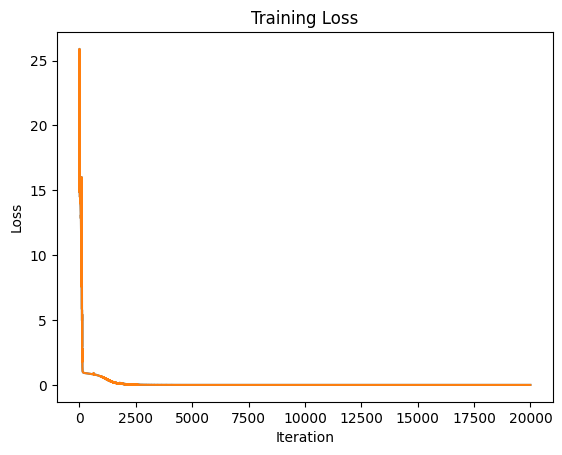

In [79]:
%matplotlib inline
import torch
import torch.nn.functional as F

NUM_ATOMS = 29

NUM_ATOM_TYPES = 5
NUM_BLOCKS = 1
HIDDEN_NF = 32
TANH_COORD_UPDATES = False
ATTENTION = False
AGGR_TYPE = "mean"

NUM_ITERS = 20000
LR = 0.05

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

keep = []
for i, d in enumerate(dataset):
    if d.num_nodes == NUM_ATOMS:
        keep.append(i)
    if len(keep) >= 1:
        break
filtered_dataset = dataset.index_select(keep)

real_mol = filtered_dataset[0]

print(f"Number of nodes: {real_mol.num_nodes}")
real_pos = real_mol.pos
# Zero center the real molecule positions
real_pos = real_pos - real_pos.mean(dim=0)
real_pos = real_pos / real_pos.std(dim=0)
real_pos = real_pos.to(device)
real_pos_flattened = real_pos.view(-1, 3)
print(f"Center of mass of real molecule positions: {real_pos.mean(dim=0)}")
print(f"Std of real molecule positions: {real_pos.std(dim=0)}")

real_types = real_mol.real_atom_types
real_types = real_types.to(device)
print(f"Real molecule atom types shape: {real_types.shape}")

# Sample noise once with the same shape
# as the real molecules
pos_noise = torch.randn_like(real_mol.pos, device=device)
pos_noise = pos_noise - pos_noise.mean(dim=0)
pos_noise = pos_noise / pos_noise.std(dim=0)
dense_edge_index = real_mol.dense_edge_index
dense_edge_index = dense_edge_index.to(device)
type_noise = torch.randn((real_mol.num_nodes, NUM_ATOM_TYPES), device=device)

# Instantiate model and optimizer
model = EGNN(
    num_atom_types=NUM_ATOM_TYPES,
    num_blocks=NUM_BLOCKS,
    hidden_nf=HIDDEN_NF,
    attention=ATTENTION,
    tanh_coord_updates=TANH_COORD_UPDATES,
    aggr_type=AGGR_TYPE,
)
model = model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

loss_list = []
for iter in range(NUM_ITERS):
    optimizer.zero_grad()
    # Forward pass
    gen_pos, gen_type_logits = model(pos_noise, type_noise, dense_edge_index)

    # Center generated positions
    gen_pos = gen_pos - gen_pos.mean(dim=0)

    # Convert logits to probs and project them to sphere
    gen_types_probs = F.softmax(gen_type_logits, dim=-1)
    gen_types_sphere = probs_to_sphere(gen_types_probs)

    # Turn gen_types into N_GEN_MOLS x NUM_ATOMS x 5
    # Since we only have one molecule here we can just unsqueeze it
    # but we leave the comment for debugging purporses
    gen_types_sphere_reshaped = gen_types_sphere.view(1, NUM_ATOMS, NUM_ATOM_TYPES)
    real_types_reshaped = real_types.view(1, NUM_ATOMS, NUM_ATOM_TYPES)

    # Since we are working with a single gen_mol and a single real_mol
    # we can just compute the drifting field as the differece,
    # but leave the other loss as reference
    V_pos = real_pos - gen_pos
    # V_pos = compute_euclidean_drifting_field(gen_pos, real_pos)
    V_types = compute_geodesic_drifting_field(gen_types_sphere_reshaped, real_types_reshaped)

    target_pos = (gen_pos + V_pos).detach()
    pos_loss = F.mse_loss(gen_pos, target_pos)

    target_types = sphere_exp(gen_types_sphere_reshaped, V_types).detach()
    type_loss = geodesic_distance(gen_types_sphere_reshaped, target_types).pow(2).sum(dim=-1)

    loss = pos_loss + type_loss.mean()

    loss.backward()
    optimizer.step()
    loss_list.append(loss.mean().item())
    if (iter + 1) % 100 == 0:
        print(f"Iter {iter}: Loss = {loss.mean().item()}")

plot_loss(loss_list)

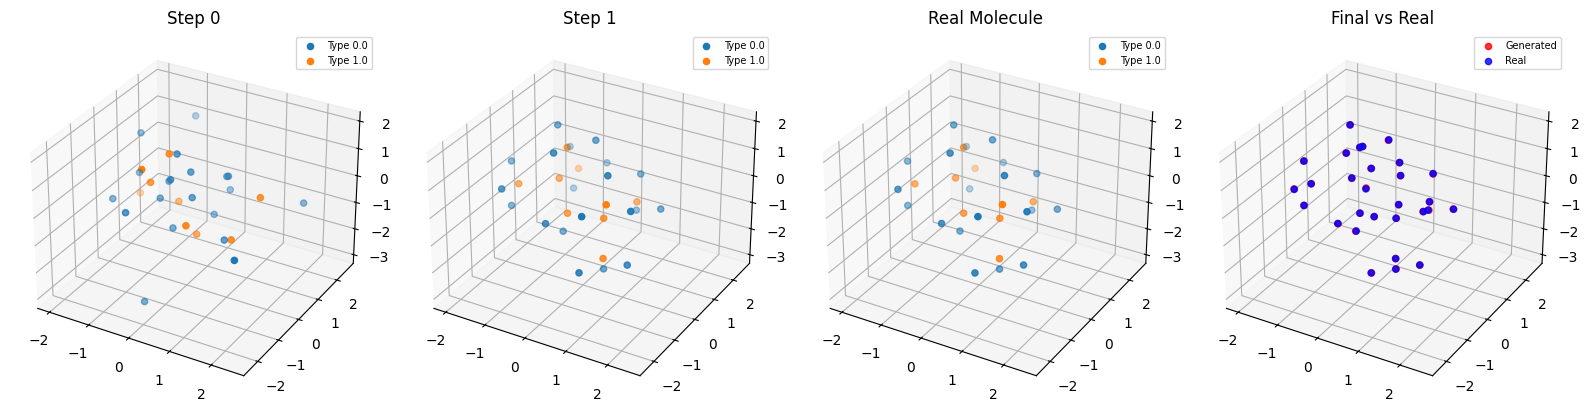

In [81]:
gen_pos, gen_types, pos_list = model(
    pos_noise, type_noise, dense_edge_index, return_change_in_pos=True
)
gen_pos = gen_pos - gen_pos.mean(dim=0)

# Center pos_list
pos_list = [p - p.mean(dim=0) for p in pos_list]

gen_types_argmax = gen_types.argmax(dim=1).float()
real_types_argmax = real_types.argmax(dim=1).float()

# pos_list is e.g. the trajectory saved during your diffusion reverse process
visualize_progression_with_real(
    pos_list=pos_list,
    gen_types=gen_types_argmax,
    real_pos=real_pos,
    real_types=real_types_argmax,
    max_steps=len(pos_list)        # shows 6 evenly-spaced snapshots + real on the right
)

# Sample Multiple Noise - ONCE

Number of nodes: 29
Iter 99: Loss = 13.756217002868652
Iter 199: Loss = 12.171338081359863
Iter 299: Loss = 13.206064224243164
Iter 399: Loss = 8.602640151977539
Iter 499: Loss = 7.124344825744629
Iter 599: Loss = 0.3617505729198456
Iter 699: Loss = 0.14944030344486237
Iter 799: Loss = 0.09732063859701157
Iter 899: Loss = 0.08997870236635208
Iter 999: Loss = 0.08687420189380646
Iter 1099: Loss = 0.08516710251569748
Iter 1199: Loss = 0.08409738540649414
Iter 1299: Loss = 0.08336950838565826
Iter 1399: Loss = 0.08284613490104675
Iter 1499: Loss = 0.08245476335287094
Iter 1599: Loss = 0.08215158432722092
Iter 1699: Loss = 0.08191150426864624
Iter 1799: Loss = 0.08171659708023071
Iter 1899: Loss = 0.08155617862939835
Iter 1999: Loss = 0.0814208835363388
Iter 2099: Loss = 0.08130703866481781
Iter 2199: Loss = 0.08120943605899811
Iter 2299: Loss = 0.08112478256225586
Iter 2399: Loss = 0.08105100691318512
Iter 2499: Loss = 0.08098586648702621
Iter 2599: Loss = 0.08092913776636124
Iter 2699: L

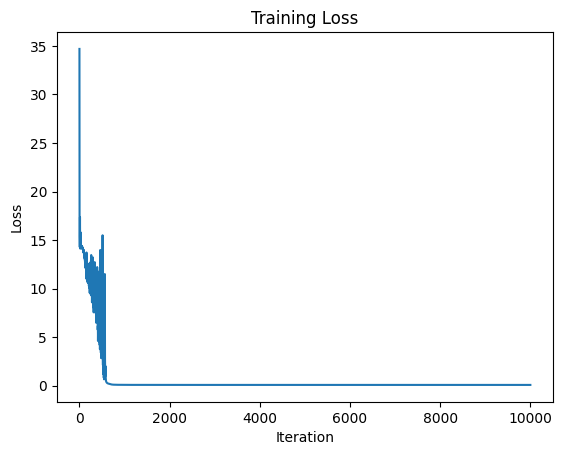

In [ ]:
%matplotlib inline
import torch
import torch.nn.functional as F

NUM_ATOMS = 29
N_GEN_MOLS = 10

NUM_ATOM_TYPES = 5
NUM_BLOCKS = 1
HIDDEN_NF = 32
TANH_COORD_UPDATES = False
ATTENTION = False
AGGR_TYPE = "mean"

NUM_ITERS = 10000
LR = 0.05

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

keep = []
for i, d in enumerate(dataset):
    if d.num_nodes == NUM_ATOMS:
        keep.append(i)
    if len(keep) >= 1:
        break
filtered_dataset = dataset.index_select(keep)

real_mol = filtered_dataset[0]

print(f"Number of nodes: {real_mol.num_nodes}")
real_pos = real_mol.pos
# Zero center the real molecule positions
real_pos = real_pos - real_pos.mean(dim=0)
real_pos = real_pos / real_pos.std(dim=0)
real_pos = real_pos.to(device)

real_types = real_mol.real_atom_types
real_types = real_types.to(device)
real_types_reshaped = real_types.view(1, NUM_ATOMS, NUM_ATOM_TYPES)

real_types_flattened = real_types.view(1, -1)
real_pos_flattened = real_pos.view(1, -1)

# Instantiate model and optimizer
model = EGNN(
    num_atom_types=NUM_ATOM_TYPES,
    num_blocks=NUM_BLOCKS,
    hidden_nf=HIDDEN_NF,
    attention=ATTENTION,
    tanh_coord_updates=TANH_COORD_UPDATES,
    aggr_type=AGGR_TYPE,
)
model = model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

# Sample noise once with the same shape
# as the real molecules
batch_vec = torch.arange(N_GEN_MOLS, device=device).repeat_interleave(real_mol.num_nodes)
pos_noise = torch.randn((N_GEN_MOLS * real_mol.num_nodes, 3), device=device)
pos_noise = center_positions_per_mol(pos_noise, batch_vec)
pos_noise = pos_noise / pos_noise.std(dim=0)
type_noise = torch.randn((N_GEN_MOLS * real_mol.num_nodes, NUM_ATOM_TYPES), device=device)

dense_edge_index = real_mol.dense_edge_index
edge_index_list = []
for offset in range(N_GEN_MOLS):
    offset_edge_index = dense_edge_index + offset * real_mol.num_nodes
    edge_index_list.append(offset_edge_index)
dense_edge_index = torch.cat(edge_index_list, dim=1)
dense_edge_index = dense_edge_index.to(device)

loss_list = []
for iter in range(NUM_ITERS):
    optimizer.zero_grad()
    # Forward pass
    gen_pos, gen_type_logits = model(pos_noise, type_noise, dense_edge_index)

    # Center generated positions per molecule
    gen_pos = center_positions_per_mol(gen_pos, batch_vec)

    # Convert logits to probs and project them to sphere
    gen_types_probs = F.softmax(gen_type_logits, dim=-1)
    gen_types_sphere = probs_to_sphere(gen_types_probs)

    # Turn gen_types into N_GEN_MOLS x NUM_ATOMS x 5
    gen_types_sphere_reshaped = gen_types_sphere.view(
        N_GEN_MOLS, NUM_ATOMS, NUM_ATOM_TYPES
    )

    # Reshape to get right positions
    gen_pos = gen_pos.view(N_GEN_MOLS, -1)

    V_pos = compute_euclidean_drifting_field(gen_pos, real_pos_flattened)
    V_types = compute_geodesic_drifting_field(gen_types_sphere_reshaped, real_types_reshaped)

    target_pos = (gen_pos + V_pos).detach()
    pos_loss = F.mse_loss(gen_pos, target_pos)

    target_types = sphere_exp(gen_types_sphere_reshaped, V_types).detach()
    type_loss = geodesic_distance(gen_types_sphere_reshaped, target_types).pow(2).sum(dim=-1)

    loss = pos_loss + type_loss.mean()

    loss.backward()
    optimizer.step()
    loss_list.append(loss.mean().item())
    if (iter + 1) % 100 == 0:
        print(f"Iter {iter}: Loss = {loss.mean().item()}")

plot_loss(loss_list)

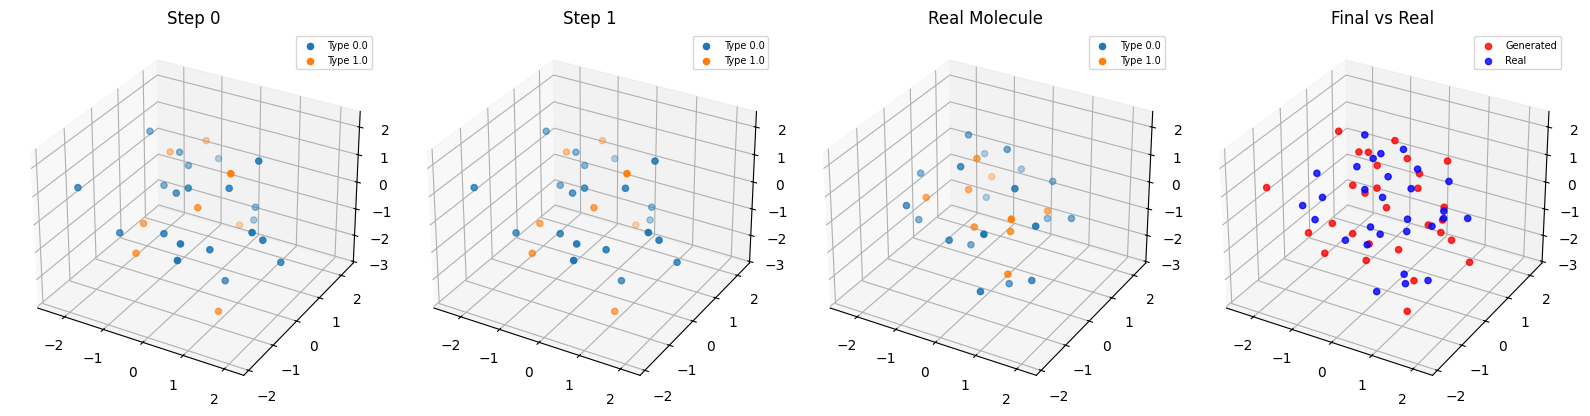

In [100]:
gen_pos, gen_types, pos_list = model(
    pos_noise, type_noise, dense_edge_index, return_change_in_pos=True
)
gen_pos = center_positions_per_mol(gen_pos, batch_vec)

gen_pos_flattened = gen_pos.view(N_GEN_MOLS, -1)
sorted_pos, closest_indices = get_sorted_mols(gen_pos_flattened, real_pos_flattened)

SELECTED_IDX = 0

selected_pos_list = []
for gen_pos_step in pos_list:
    gen_pos_step = gen_pos_step.view(N_GEN_MOLS, -1)
    ge_pos_step = gen_pos_step[SELECTED_IDX]
    gen_pos_step = ge_pos_step.view(-1, 3)
    gen_pos_step = gen_pos_step - gen_pos_step.mean(dim=0)
    selected_pos_list.append(gen_pos_step)

viz_types = gen_types.reshape(N_GEN_MOLS, -1)
viz_types = viz_types[closest_indices[SELECTED_IDX]]

viz_types = viz_types.view(-1, NUM_ATOM_TYPES).argmax(dim=1).float()
real_types_argmax = real_types.view(-1, NUM_ATOM_TYPES).argmax(dim=1).float()

# pos_list is e.g. the trajectory saved during your diffusion reverse process
visualize_progression_with_real(
    pos_list=selected_pos_list,
    gen_types=viz_types,
    real_pos=real_pos,
    real_types=real_types_argmax,
    max_steps=len(selected_pos_list)
)

# Align Output -> Multiple Noise

Number of nodes: 29
Iter 99: Loss = 14.112227439880371
Iter 199: Loss = 11.307075500488281
Iter 299: Loss = 10.399859428405762
Iter 399: Loss = 7.299180507659912
Iter 499: Loss = 1.9277971982955933
Iter 599: Loss = 0.8331637382507324
Iter 699: Loss = 0.8233742117881775
Iter 799: Loss = 0.8213229179382324
Iter 899: Loss = 0.8205461502075195
Iter 999: Loss = 0.8201743960380554
Iter 1099: Loss = 0.8199679255485535
Iter 1199: Loss = 0.8198442459106445
Iter 1299: Loss = 0.8197643160820007
Iter 1399: Loss = 0.8197113871574402
Iter 1499: Loss = 0.8196754455566406
Iter 1599: Loss = 0.8196479082107544
Iter 1699: Loss = 0.8196298480033875
Iter 1799: Loss = 0.8196159601211548
Iter 1899: Loss = 0.8196067214012146
Iter 1999: Loss = 0.8195980191230774
Iter 2099: Loss = 0.8195951581001282
Iter 2199: Loss = 0.8195889592170715
Iter 2299: Loss = 0.8195871710777283
Iter 2399: Loss = 0.8195852637290955
Iter 2499: Loss = 0.8195858001708984
Iter 2599: Loss = 0.8195841908454895
Iter 2699: Loss = 0.8195840120

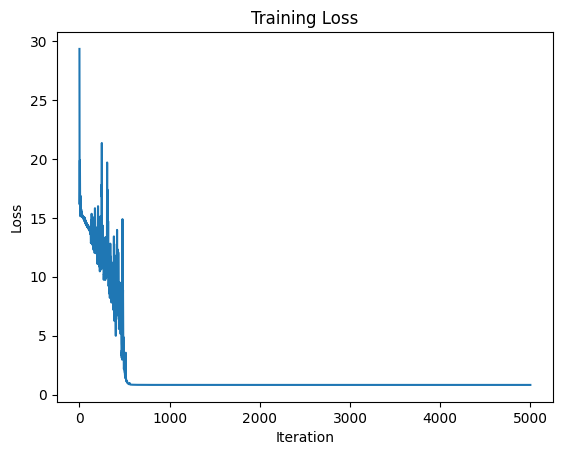

In [119]:
import torch
import torch.nn.functional as F

NUM_ATOMS = 29
N_GEN_MOLS = 10

NUM_ATOM_TYPES = 5
NUM_BLOCKS = 2
HIDDEN_NF = 64
TANH_COORD_UPDATES = False
ATTENTION = False
AGGR_TYPE = "mean"

NUM_ITERS = 5000
LR = 0.05

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

keep = []
for i, d in enumerate(dataset):
    if d.num_nodes == NUM_ATOMS:
        keep.append(i)
    if len(keep) >= 1:
        break
filtered_dataset = dataset.index_select(keep)

real_mol = filtered_dataset[0]

print(f"Number of nodes: {real_mol.num_nodes}")
real_pos = real_mol.pos
# Zero center the real molecule positions
real_pos = real_pos - real_pos.mean(dim=0)
real_pos = real_pos / real_pos.std(dim=0)
real_pos = real_pos.to(device)

real_types = real_mol.real_atom_types
real_types = real_types.to(device)
real_types_reshaped = real_types.view(1, NUM_ATOMS, NUM_ATOM_TYPES)

real_types_flattened = real_types.view(1, -1)
real_pos_flattened = real_pos.view(1, -1)

# Instantiate model and optimizer
model = EGNN(
    num_atom_types=NUM_ATOM_TYPES,
    num_blocks=NUM_BLOCKS,
    hidden_nf=HIDDEN_NF,
    attention=ATTENTION,
    tanh_coord_updates=TANH_COORD_UPDATES,
    aggr_type=AGGR_TYPE,
)
model = model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

# Sample noise once with the same shape
# as the real molecules
batch_vec = torch.arange(N_GEN_MOLS, device=device).repeat_interleave(real_mol.num_nodes)
pos_noise = torch.randn((N_GEN_MOLS * real_mol.num_nodes, 3), device=device)
pos_noise = center_positions_per_mol(pos_noise, batch_vec)
pos_noise = pos_noise / pos_noise.std(dim=0)
type_noise = torch.randn((N_GEN_MOLS * real_mol.num_nodes, NUM_ATOM_TYPES), device=device)

dense_edge_index = real_mol.dense_edge_index
edge_index_list = []
for offset in range(N_GEN_MOLS):
    offset_edge_index = dense_edge_index + offset * real_mol.num_nodes
    edge_index_list.append(offset_edge_index)
dense_edge_index = torch.cat(edge_index_list, dim=1)
dense_edge_index = dense_edge_index.to(device)

loss_list = []
for iter in range(NUM_ITERS):
    optimizer.zero_grad()

    # Forward pass
    gen_pos, gen_type_logits = model(pos_noise, type_noise, dense_edge_index)

    # Center generated and align positions per molecule
    gen_pos = center_positions_per_mol(gen_pos, batch_vec)
    gen_pos = kabsch_align_pyg(
        gen_pos,
        real_pos.repeat(N_GEN_MOLS, 1),
        batch_vec,
        N_GEN_MOLS,
    )

    # Convert logits to probs and project them to sphere
    gen_types_probs = F.softmax(gen_type_logits, dim=-1)
    gen_types_sphere = probs_to_sphere(gen_types_probs)

    # Turn gen_types into N_GEN_MOLS x NUM_ATOMS x 5
    gen_types_sphere_reshaped = gen_types_sphere.view(
        N_GEN_MOLS, NUM_ATOMS, NUM_ATOM_TYPES
    )

    # Reshape to get right positions
    gen_pos = gen_pos.view(N_GEN_MOLS, -1)

    V_pos = compute_euclidean_drifting_field(gen_pos, real_pos_flattened)
    V_types = compute_geodesic_drifting_field(gen_types_sphere_reshaped, real_types_reshaped)

    target_pos = (gen_pos + V_pos).detach()
    pos_loss = F.mse_loss(gen_pos, target_pos)

    target_types = sphere_exp(gen_types_sphere_reshaped, V_types).detach()
    type_loss = geodesic_distance(gen_types_sphere_reshaped, target_types).pow(2).sum(dim=-1)

    loss = pos_loss + type_loss.mean()

    loss.backward()
    optimizer.step()
    loss_list.append(loss.mean().item())
    if (iter + 1) % 100 == 0:
        print(f"Iter {iter}: Loss = {loss.mean().item()}")

plot_loss(loss_list)

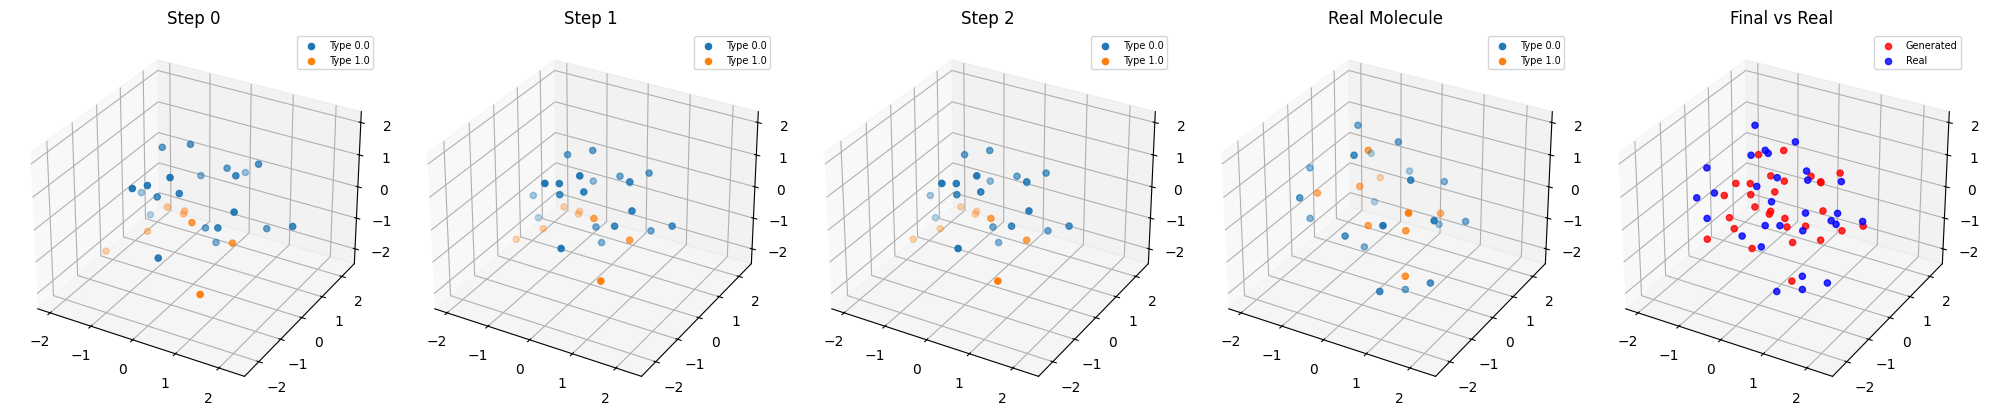

In [120]:
gen_pos, gen_types, pos_list = model(
    pos_noise, type_noise, dense_edge_index, return_change_in_pos=True
)
gen_pos = center_positions_per_mol(gen_pos, batch_vec)
gen_pos = kabsch_align_pyg(
    gen_pos,
    real_pos.repeat(N_GEN_MOLS, 1),
    batch_vec,
    N_GEN_MOLS,
)

gen_pos_flattened = gen_pos.view(N_GEN_MOLS, -1)
sorted_pos, closest_indices = get_sorted_mols(gen_pos_flattened, real_pos_flattened)

SELECTED_IDX = 9

selected_pos_list = []
for gen_pos_step in pos_list:
    gen_pos_step = gen_pos_step.view(N_GEN_MOLS, -1)
    ge_pos_step = gen_pos_step[SELECTED_IDX]
    gen_pos_step = ge_pos_step.view(-1, 3)
    gen_pos_step = gen_pos_step - gen_pos_step.mean(dim=0)
    gen_pos_step = kabsch_align(gen_pos_step, real_pos)
    selected_pos_list.append(gen_pos_step)

viz_types = gen_types.reshape(N_GEN_MOLS, -1)
viz_types = viz_types[closest_indices[SELECTED_IDX]]

viz_types = viz_types.view(-1, NUM_ATOM_TYPES).argmax(dim=1).float()
real_types_argmax = real_types.view(-1, NUM_ATOM_TYPES).argmax(dim=1).float()

# pos_list is e.g. the trajectory saved during your diffusion reverse process
visualize_progression_with_real(
    pos_list=selected_pos_list,
    gen_types=viz_types,
    real_pos=real_pos,
    real_types=real_types_argmax,
    max_steps=len(selected_pos_list)
)